# Phase 1: Setting Up the Environment and Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

C:\Users\sreer\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sreer\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data = pd.read_csv('C:/Users/sreer/Downloads/dynamic_pricing.csv')

In [3]:
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [4]:
print("Data Missing Values:\n", data.isnull().sum())

Data Missing Values:
 Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64


In [5]:
print("Data Types:\n", data.dtypes)

Data Types:
 Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category           object
Customer_Loyalty_Status     object
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking             object
Vehicle_Type                object
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
dtype: object


In [6]:
print(data.describe())

       Number_of_Riders  Number_of_Drivers  Number_of_Past_Rides  \
count       1000.000000        1000.000000           1000.000000   
mean          60.372000          27.076000             50.031000   
std           23.701506          19.068346             29.313774   
min           20.000000           5.000000              0.000000   
25%           40.000000          11.000000             25.000000   
50%           60.000000          22.000000             51.000000   
75%           81.000000          38.000000             75.000000   
max          100.000000          89.000000            100.000000   

       Average_Ratings  Expected_Ride_Duration  Historical_Cost_of_Ride  
count      1000.000000              1000.00000              1000.000000  
mean          4.257220                99.58800               372.502623  
std           0.435781                49.16545               187.158756  
min           3.500000                10.00000                25.993449  
25%           3.8

# Phase 2: Exploratory Data Analysis (EDA)

In [7]:
print("Shape of the dataset:", data.shape)

Shape of the dataset: (1000, 10)


In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.2+ KB
None


In [9]:
# Convert all column names to lowercase and replace spaces with underscores
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
# Replace special characters in column names
data.columns = data.columns.str.replace(r'[^\w\s]', '', regex=True)

In [11]:
# Display updated column names
print(data.columns)

Index(['number_of_riders', 'number_of_drivers', 'location_category',
       'customer_loyalty_status', 'number_of_past_rides', 'average_ratings',
       'time_of_booking', 'vehicle_type', 'expected_ride_duration',
       'historical_cost_of_ride'],
      dtype='object')


In [12]:
data

,number_of_riders,number_of_drivers,location_category,customer_loyalty_status,number_of_past_rides,average_ratings,time_of_booking,vehicle_type,expected_ride_duration,historical_cost_of_ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


In [13]:
print("Missing Values:\n", data.isnull().sum())

Missing Values:
 number_of_riders           0
number_of_drivers          0
location_category          0
customer_loyalty_status    0
number_of_past_rides       0
average_ratings            0
time_of_booking            0
vehicle_type               0
expected_ride_duration     0
historical_cost_of_ride    0
dtype: int64


# Analyze the Target Variable

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

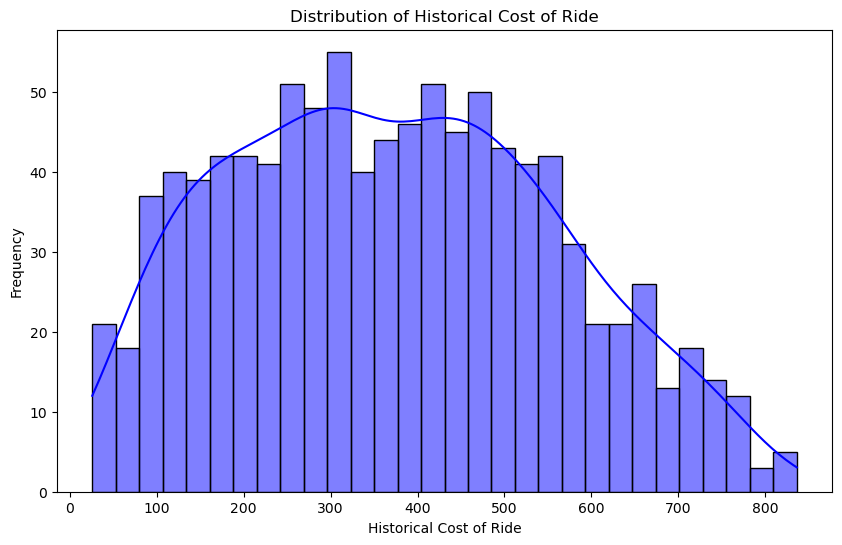

In [15]:
# Distribution plot for the target variable
plt.figure(figsize=(10, 6))
sns.histplot(data['historical_cost_of_ride'], kde=True, bins=30, color='blue')
plt.title('Distribution of Historical Cost of Ride')
plt.xlabel('Historical Cost of Ride')
plt.ylabel('Frequency')
plt.show()

# Analyze Numerical Features

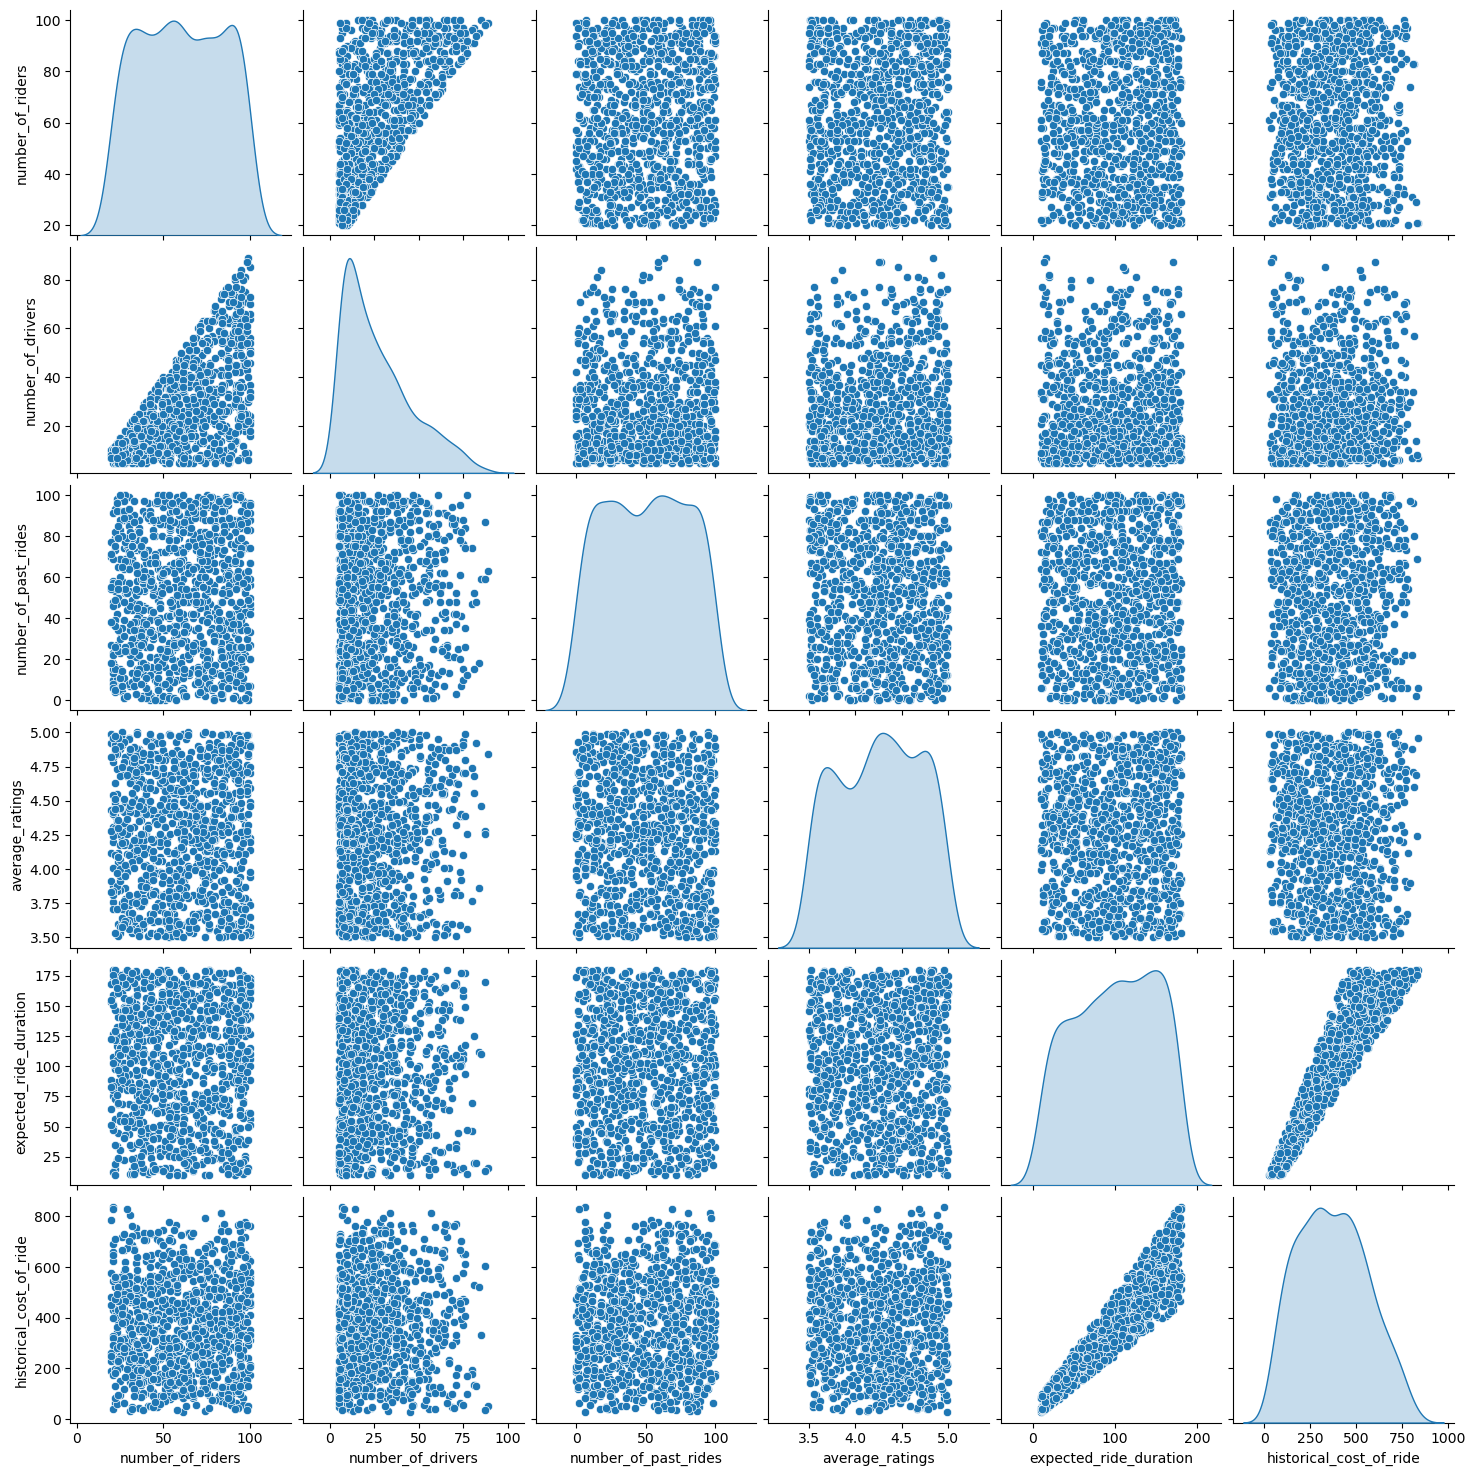

In [16]:
# Pairplot for numerical features and target variable
numerical_features = ['number_of_riders', 'number_of_drivers', 'number_of_past_rides', 
                      'average_ratings', 'expected_ride_duration', 'historical_cost_of_ride']

sns.pairplot(data[numerical_features], diag_kind='kde', height=2.5)
plt.show()

# Correlation Analysis

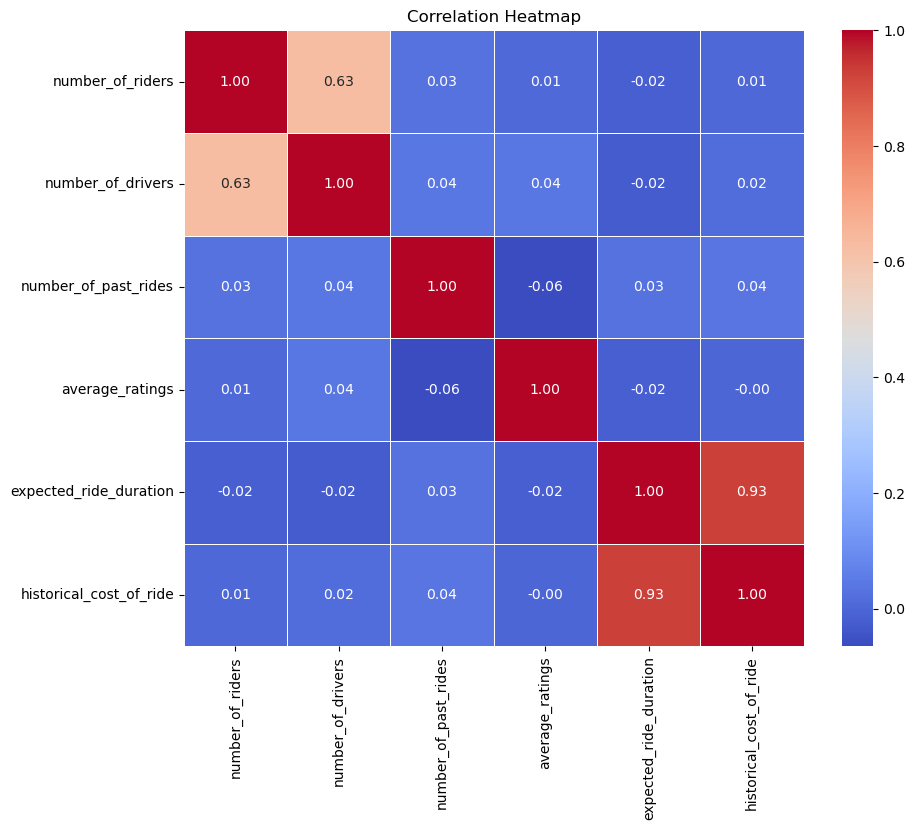

In [17]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = data[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Analyze Categorical Features

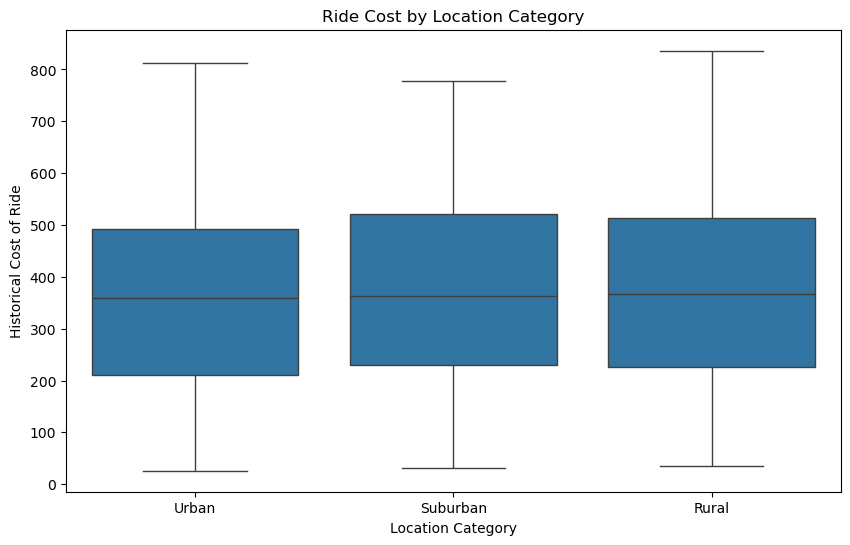

In [18]:
# Boxplot for Location_Category and Historical_Cost_of_Ride
plt.figure(figsize=(10, 6))
sns.boxplot(x='location_category', y='historical_cost_of_ride', data=data)
plt.title('Ride Cost by Location Category')
plt.xlabel('Location Category')
plt.ylabel('Historical Cost of Ride')
plt.show()

C:\Users\sreer\AppData\Local\Temp\ipykernel_33656\3969087940.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='vehicle_type', y='historical_cost_of_ride', data=data, ci=None)


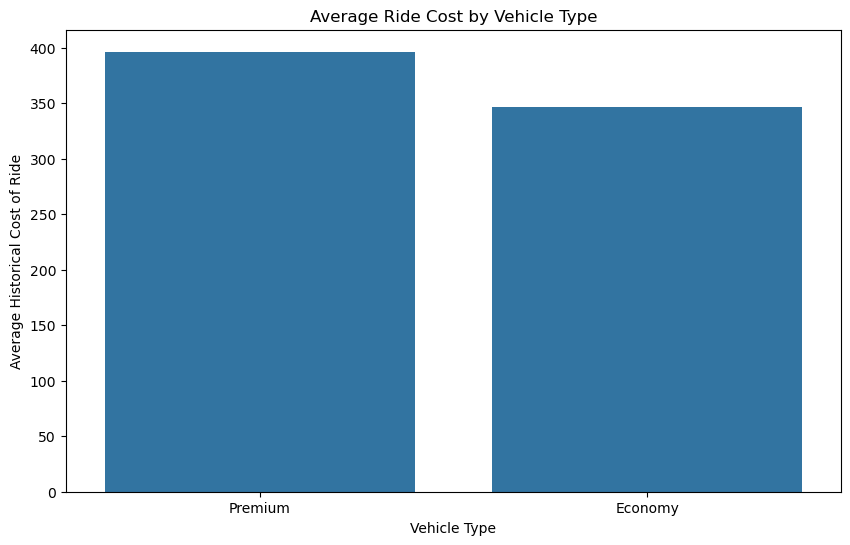

In [19]:
# Bar plot for Vehicle_Type and Historical_Cost_of_Ride
plt.figure(figsize=(10, 6))
sns.barplot(x='vehicle_type', y='historical_cost_of_ride', data=data, ci=None)
plt.title('Average Ride Cost by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Historical Cost of Ride')
plt.show()

# Time-Based Analysis

C:\Users\sreer\AppData\Local\Temp\ipykernel_33656\1493919910.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='time_of_booking', y='historical_cost_of_ride', data=data, ci=None, palette='viridis')
C:\Users\sreer\AppData\Local\Temp\ipykernel_33656\1493919910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time_of_booking', y='historical_cost_of_ride', data=data, ci=None, palette='viridis')


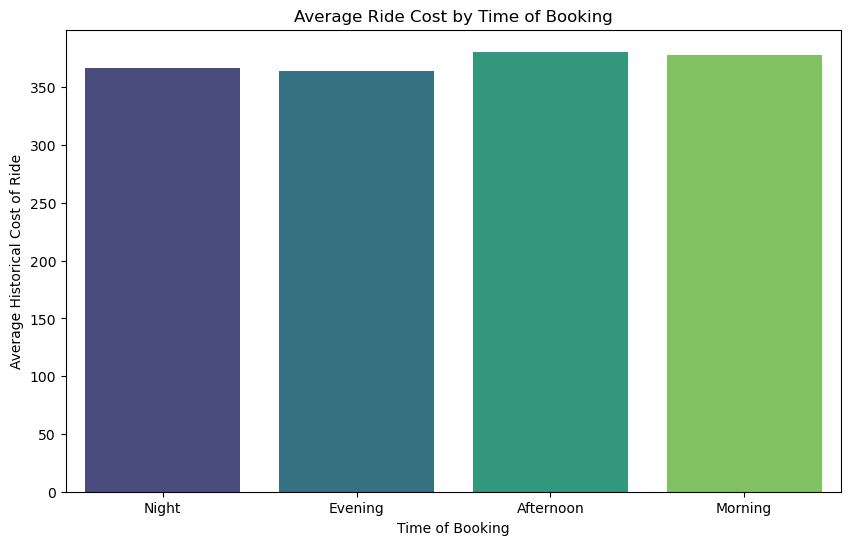

In [20]:
# Bar plot for Time_of_Booking and Historical_Cost_of_Ride
plt.figure(figsize=(10, 6))
sns.barplot(x='time_of_booking', y='historical_cost_of_ride', data=data, ci=None, palette='viridis')
plt.title('Average Ride Cost by Time of Booking')
plt.xlabel('Time of Booking')
plt.ylabel('Average Historical Cost of Ride')
plt.show()

# Outlier Detection

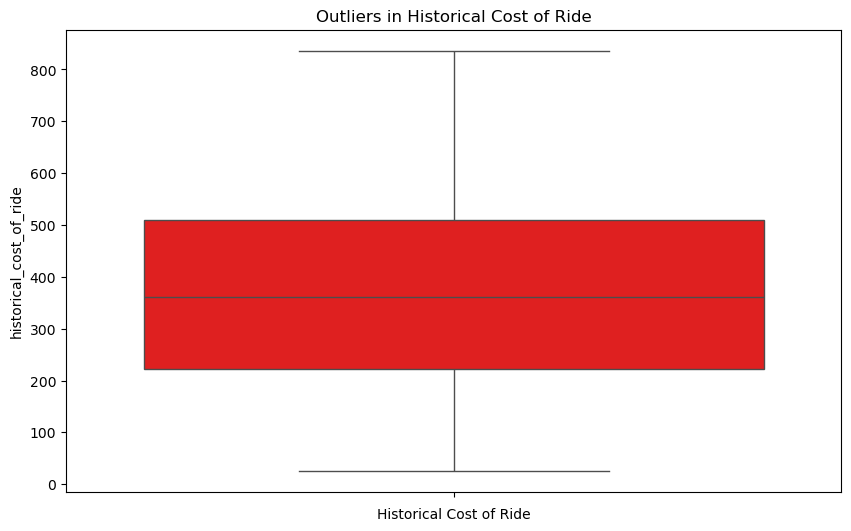

In [21]:
# Boxplot for detecting outliers in the target variable
plt.figure(figsize=(10, 6))
sns.boxplot(data['historical_cost_of_ride'], color='red')
plt.title('Outliers in Historical Cost of Ride')
plt.xlabel('Historical Cost of Ride')
plt.show()

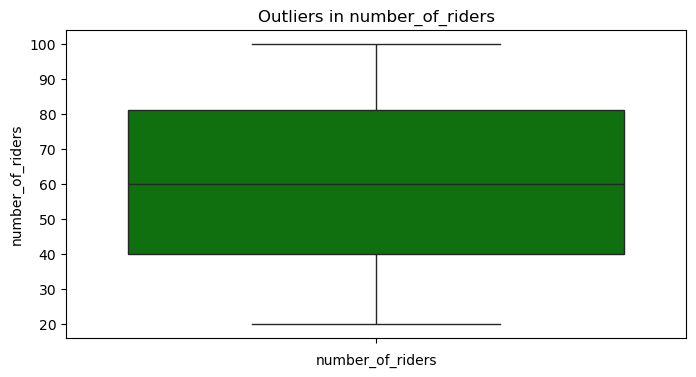

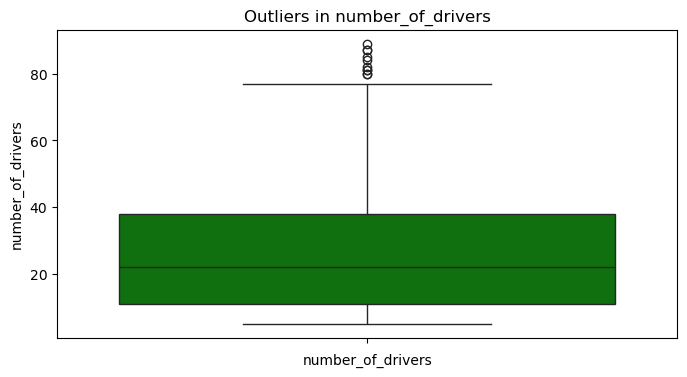

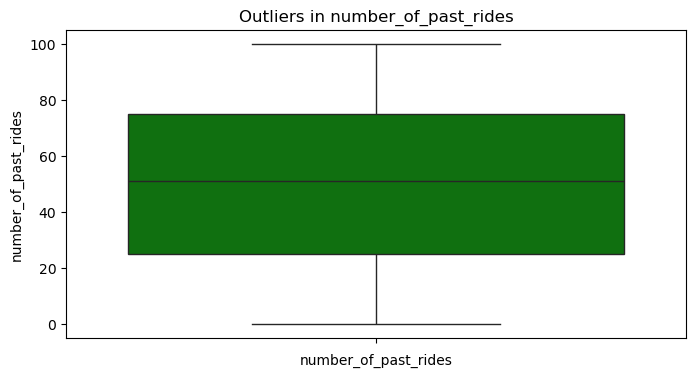

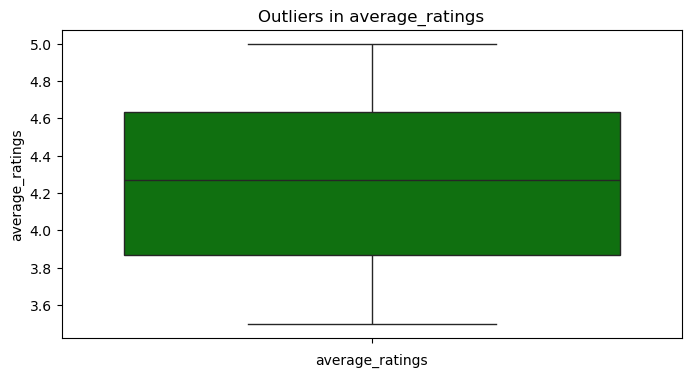

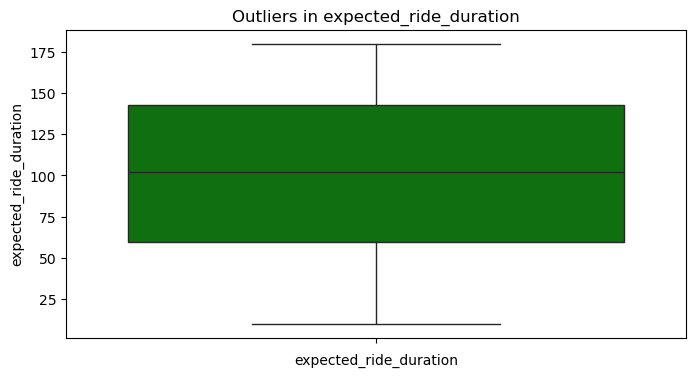

In [22]:
# Outlier detection for other numerical features
for feature in numerical_features[:-1]:  # Exclude target variable
    plt.figure(figsize=(8, 4))
    sns.boxplot(data[feature], color='green')
    plt.title(f'Outliers in {feature}')
    plt.xlabel(feature)
    plt.show()

# Demand-Supply Ratio (Feature Engineering)

In [23]:
# Create Demand-Supply Ratio
data['demand_supply_ratio'] = data['number_of_riders'] / data['number_of_drivers']

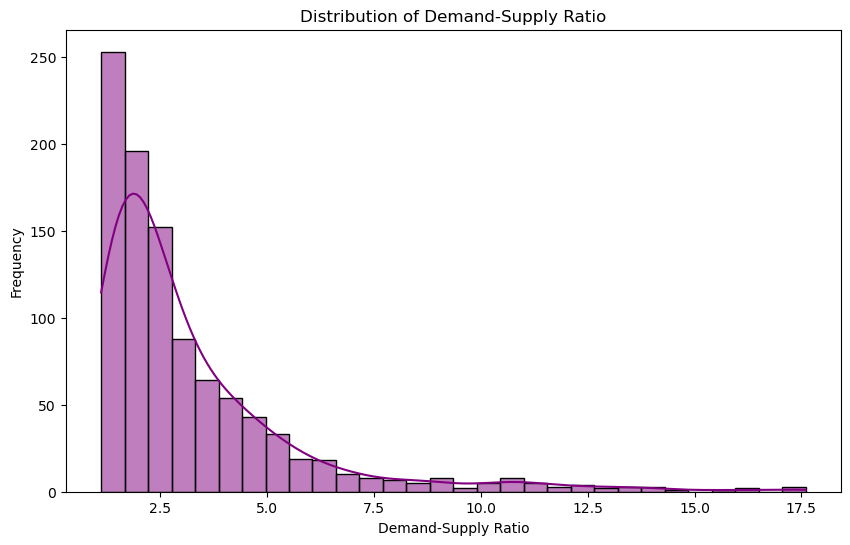

In [24]:
# Distribution plot for Demand-Supply Ratio
plt.figure(figsize=(10, 6))
sns.histplot(data['demand_supply_ratio'], kde=True, bins=30, color='purple')
plt.title('Distribution of Demand-Supply Ratio')
plt.xlabel('Demand-Supply Ratio')
plt.ylabel('Frequency')
plt.show()

In [25]:
# Correlation with the target variable
print("Correlation with Historical Cost of Ride:")
print(data[['demand_supply_ratio', 'historical_cost_of_ride']].corr())

Correlation with Historical Cost of Ride:
                         demand_supply_ratio  historical_cost_of_ride
demand_supply_ratio                 1.000000                -0.094372
historical_cost_of_ride            -0.094372                 1.000000


# Findings

## Key Insights from EDA

### 1. Target Variable (`Historical_Cost_of_Ride`)

- The distribution of ride costs is slightly **right-skewed**, indicating the presence of high-cost rides.
- Outliers are observed in the higher range of ride costs, which may need to be addressed during preprocessing.

### 2. Numerical Features

- `Expected_Ride_Duration` shows a strong positive correlation with `Historical_Cost_of_Ride`, indicating that longer rides generally cost more.
- Features like `Number_of_Riders` and `Number_of_Drivers` have moderate correlations with the target variable.
- The pair plots highlight some linear relationships between numerical features and the target variable.

### 3. Categorical Features

- **Location Category:** Urban areas tend to have higher ride costs compared to rural and suburban areas.
- **Vehicle Type:** Premium vehicles are associated with significantly higher ride costs compared to Economy vehicles.
- **Time of Booking:** Rides booked at night are generally more expensive, indicating a potential demand-supply imbalance.

### 4. Demand-Supply Ratio

- A new feature, `Demand_Supply_Ratio`, was created to represent the ratio of `Number_of_Riders` to `Number_of_Drivers`.
- Higher demand-supply ratios are moderately correlated with higher ride costs, supporting the potential use of demand-supply factors in dynamic pricing strategies.

### 5. Outliers

- Significant outliers are observed in the target variable and some numerical features (e.g., `Expected_Ride_Duration`).
- These may represent exceptional scenarios or data errors and should be investigated during preprocessing.

## Visualizations

- The distribution of ride costs and numerical features was analyzed using histograms and scatter plots.
- Box plots and bar plots were used to examine the influence of categorical variables such as `Location_Category`, `Vehicle_Type`, and `Time_of_Booking`.
- A correlation heatmap provided insights into relationships between numerical features and helped guide feature selection for model training.

## Next Steps

- Investigate and handle outliers and missing values, if any.
- Encode categorical features for model compatibility.
- Normalize or standardize numerical features where required.
- Incorporate `Demand_Supply_Ratio` as a feature for model training.

# Phase 3: Data Preprocessing

In [26]:
# One-Hot Encode Categorical Variables
data = pd.get_dummies(data, columns=['location_category', 'customer_loyalty_status', 
                                     'time_of_booking', 'vehicle_type'], drop_first=True)

# Verify the new columns
print("Encoded Data Columns:\n", data.columns)

Encoded Data Columns:
 Index(['number_of_riders', 'number_of_drivers', 'number_of_past_rides',
       'average_ratings', 'expected_ride_duration', 'historical_cost_of_ride',
       'demand_supply_ratio', 'location_category_Suburban',
       'location_category_Urban', 'customer_loyalty_status_Regular',
       'customer_loyalty_status_Silver', 'time_of_booking_Evening',
       'time_of_booking_Morning', 'time_of_booking_Night',
       'vehicle_type_Premium'],
      dtype='object')


In [27]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ['number_of_riders', 'number_of_drivers', 'number_of_past_rides', 
                      'average_ratings', 'expected_ride_duration']

# Apply Standard Scaling
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Verify scaled data
print(data[numerical_features].head())

   number_of_riders  number_of_drivers  number_of_past_rides  average_ratings  \
0          1.250673           0.940457             -1.263895         0.488517   
1         -0.100128           0.625642              0.749818        -0.452793   
2         -0.775528           0.205889             -1.707594        -0.613505   
3          1.208460           0.048482              0.579164         0.121177   
4          0.744122          -0.266334              0.818079        -1.118598   

   expected_ride_duration  
0               -0.195113  
1               -1.151547  
2               -0.480008  
3                0.700273  
4                1.005518  


In [28]:
# Create Demand-Supply Ratio
data['demand_supply_ratio'] = data['number_of_riders'] / data['number_of_drivers']

# Verify the new feature
print(data[['demand_supply_ratio', 'historical_cost_of_ride']].head())

   demand_supply_ratio  historical_cost_of_ride
0             1.329856               284.257273
1            -0.160040               173.874753
2            -3.766730               329.795469
3            24.926203               470.201232
4            -2.793949               579.681422


In [29]:
# Interaction Term: Expected Ride Duration × Average Ratings
data['duration_ratings_interaction'] = data['expected_ride_duration'] * data['average_ratings']

# Verify the new feature
print(data[['duration_ratings_interaction', 'historical_cost_of_ride']].head())

   duration_ratings_interaction  historical_cost_of_ride
0                     -0.095316               284.257273
1                      0.521413               173.874753
2                      0.294487               329.795469
3                      0.084857               470.201232
4                     -1.124770               579.681422


In [30]:
# Split features and target
X = data.drop(columns=['historical_cost_of_ride'])
y = data['historical_cost_of_ride']

In [31]:
# Verify shapes
print("Feature Set Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Set Shape: (1000, 15)
Target Variable Shape: (1000,)


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Verify split
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (800, 15)
Testing Set Shape: (200, 15)


# Phase 4: Model Training

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [39]:
# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

In [40]:
# Evaluate the model
print("Linear Regression Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred_lr))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
Mean Absolute Error (MAE): 52.590800391339414
Root Mean Squared Error (RMSE): 67.63802563439879
R² Score: 0.8745254589946858


In [41]:
# Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [42]:
print("Decision Tree Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R² Score:", r2_score(y_test, y_pred_dt))

Decision Tree Performance:
MAE: 72.01511549248843
RMSE: 97.19822102923031
R² Score: 0.7408862829861605


In [43]:
# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [44]:
print("Random Forest Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))

Random Forest Performance:
MAE: 55.19830939159605
RMSE: 73.99677754375422
R² Score: 0.8498243964045693


# Compare Model Performance

In [45]:
# Create a summary of model performance
performance_summary = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, y_pred_lr),
            mean_absolute_error(y_test, y_pred_dt),
            mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_dt)),
             np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    "R² Score": [r2_score(y_test, y_pred_lr),
                 r2_score(y_test, y_pred_dt),
                 r2_score(y_test, y_pred_rf)]
}

In [46]:
performance_df = pd.DataFrame(performance_summary)
print(performance_df)

               Model        MAE       RMSE  R² Score
0  Linear Regression  52.590800  67.638026  0.874525
1      Decision Tree  72.015115  97.198221  0.740886
2      Random Forest  55.198309  73.996778  0.849824
